# SINE WAVE MODEL
This script is to develop a model to predict the sine of a value. The model is deployed to a stm32 board (nucleo-l476rg). The model is converted to a tflite model to be run with the tensorflowlite-micro tflm frame work.

## Importing the needed library

In [7]:
import os

from utils import *
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

from models.Autoencoder import Conv1DDenoiser

## Generating the dataset
The data will contain numbers between 0 and 2pi, the sine function will be defined in rad.
A random uniform error is added to the sine values to give the dataset a bit of variability and see how the model will perform.
The error is centred with a mean of 0 and std 0f 0.1. This is chosen such that 95% of the error is -0.2 and 0.+2.

In [11]:
train_samples = 1000
test_samples = 300
# Generate data
x_train, s_train = generate_data(num_samples=train_samples)
x_test, s_test = generate_data(num_samples=test_samples)

In [12]:
x_train.shape

(1000,)

In [10]:
x_train = x_train.reshape(1, train_samples, 1)
s_train = s_train.reshape(1, train_samples, 1)
x_test = x_test.reshape(1, test_samples, 1)
s_test = s_test.reshape(1, test_samples, 1)

In [13]:
model_name = "neural_filter"

In [16]:
if model_name == "autoencoder_filter":
    model = Conv1DDenoiser()
    dummy_input = tf.random.normal([1, 1024, 1])  
    output = model(dummy_input)
    print(output.shape)
elif model_name == "neural_filter":
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(1,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
else:
    # Build the neural network
    model = Sequential([
        Dense(64, activation='relu', input_shape=(1,)),
        Dense(64, activation='relu'),
        Dense(1)
    ])

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(x_train, s_train, epochs=100, batch_size=1)

# Evaluate the model
loss = model.evaluate(x_test, s_test)
print(f"Test Loss: {loss}")

s_pred = model.predict(x_test)




Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1737
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1539
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1515
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1530
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1518
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1509
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1513
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1507
Epoch 9/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1507
Epoch 10/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1512
Epoch 11/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1517
Epoch 12/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1505
Epoch 13/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1508
Epoch 14/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1504
Epoch 15/100
10

In [ ]:
# check test shapes


np.float64(0.24835707650561634)

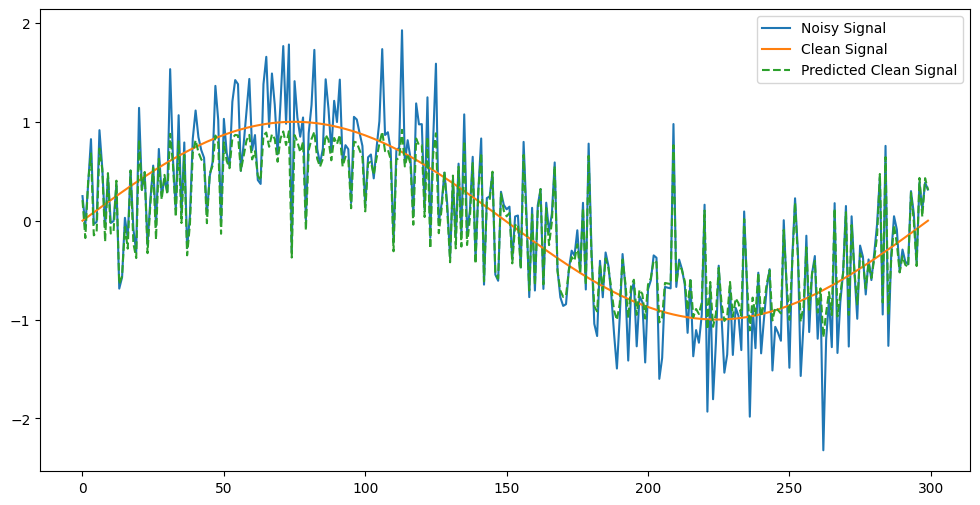

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(s_test, label='Clean Signal')
plt.plot(s_pred, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

## Saving the keras model

In [21]:
model.save(f'checkpoints/{model_name}.keras')


In [6]:
#Loading if needed
model = tf.keras.models.load_model(f'checkpoints/{model_name}.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,061 (51.02 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,708 (34.02 KB)

## Converting the model to tflite

In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# For full integer quantization
def representative_dataset_gen():
  num_calibration_steps = 300
  for _ in range(num_calibration_steps):
    # Get sample input data as a numpy array in a method of your choosing.
    test_data, _ = generate_data(num_calibration_steps)
    test_data.astype(dtype=np.float32)
    yield [test_data]

# Ensure integer input/output
# converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# converter.inference_input_type = tf.int8
# converter.inference_output_type = tf.int8
# converter.representative_dataset = representative_dataset_gen

tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmp4am_c43a/assets


INFO:tensorflow:Assets written to: /tmp/tmp4am_c43a/assets


Saved artifact at '/tmp/tmp4am_c43a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  131803262340256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131803262352928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131803262469744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131803262468688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131803262469568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131803262471328: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1759311970.826620  108484 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1759311970.826638  108484 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-10-01 11:46:10.826922: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp4am_c43a
2025-10-01 11:46:10.827505: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-10-01 11:46:10.827512: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp4am_c43a
I0000 00:00:1759311970.832339  108484 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2025-10-01 11:46:10.833316: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-10-01 11:46:10.859864: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp4am_c43a
2025-10-01 11:46:10.868009: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

## Converting the model to the c, TFlite micro format for the microcontroller

In [23]:
# Save as .tflite file
with open(f"results/{model_name}.tflite", "wb") as file:
    file.write(tflite_model)

# Breaking the byte in several lines to fit better in the c header file
tflite_model_split_line = np.array_split([format(hex_value, '#04x') for hex_value in tflite_model], len(tflite_model)//8)

C_HEADER_DIR = "STM_project"
newline = ",\n    "  # separator to avoid new line character

# Write TfLite model to a C header file
open(f"{C_HEADER_DIR}/{model_name.lower()}.h", "w").write(
f"""
#ifndef {model_name.upper()}_H
#define {model_name.upper()}_H

const unsigned int {model_name.lower()}_len = {len(tflite_model)};

const unsigned char {model_name.lower()}[{len(tflite_model)}] = {{
    {newline.join([", ".join(line) for line in tflite_model_split_line])}
}};

#endif // {model_name.upper()}_H
"""
)


28325

## Testing the converted tflite model

In [ ]:
interpreter = tf.lite.Interpreter(model_path=f"{model_name}.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_test_tflite_predict = []
for x_ in x_test:
  # Set input tensor
  interpreter.set_tensor(input_details[0]['index'], np.array([[x_]], dtype=np.float32))

  # Run the inference
  interpreter.invoke()

  y_test_tflite_predict.append(interpreter.get_tensor(output_details[0]['index']))

y_test_tflite_predict = np.array(y_test_tflite_predict)


In [ ]:
y_test_predict = model.predict(x_test)
s_test_true = np.sin(x_test)

mae_orginal_model = np.sum(np.abs(s_test_predict - s_test)) / y_test.shape[0]
mae_converted_model = np.sum(np.abs(y_test_tflite_predict - y_test)) / y_test.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].scatter(x_test, y_test_tflite_predict, marker=".", label="True value")
axes[0].scatter(x_test, y_test_true, marker=".", label="Predicted value")
axes[0].set_title("Prediction and True Values")
axes[0].set_ylabel("sin(x)")
axes[0].set_xlabel("x")
axes[0].legend()

axes[1].bar(["orginal model", "converted model"], [mae_orginal_model, mae_converted_model])
axes[1].set_title("The effect of coversion to model accuracy")
axes[1].set_ylabel("mae")
axes[1].set_xlabel("model type")

plt.show()

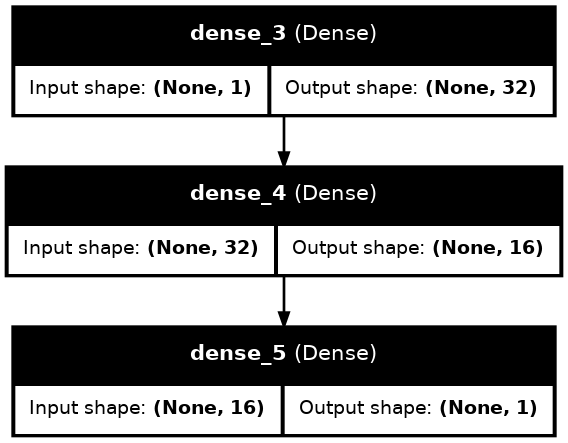

In [24]:
from tensorflow.keras.utils import plot_model

plot_model(model,
           to_file='model.png',
           show_shapes=True,
           show_layer_names=True,
           expand_nested=True,   # show inner layers if nested
           dpi=96)
